In [21]:
#!/usr/bin/env python

import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.spatial.distance import cdist
#from sklearn.utils import graph_shortest_path
from scipy.sparse.csgraph import dijkstra
from scipy.spatial.transform import Rotation

from isomap import make_adjacency, isomap, plot_graph
from sklearn.decomposition import PCA

## Generate simple data `m[3, N]`

In [18]:
n = 20
N = 20*20
Y, X = np.mgrid[:n, :n]


In [12]:
R = Rotation.from_rotvec([1, 0, 1]).as_matrix()
XYZ = (R @ np.stack([X, Y, np.ones_like(X)], -1)[..., None]).squeeze(-1)
print(f"{XYZ.shape = }")


XYZ.shape = (20, 20, 3)


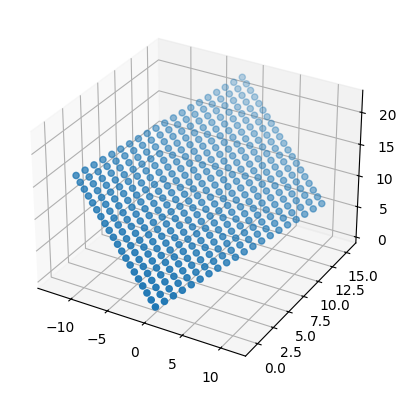

In [17]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*np.moveaxis(XYZ, -1, 0))

In [19]:
m = np.moveaxis(XYZ.reshape(N, 3), 0, 1)
print(f"{m.shape = }")

m.shape = (3, 400)


In [20]:
print(f"{m[:, 0] = }")
print(f"{m[:, 19] = }")
print(f"{m[:, N-20] = }")
print(f"{m[:, N-21] = }")

m[:, 0] = array([ 0.42202815, -0.698456  ,  0.57797185])
m[:, 19] = array([11.40349325, 12.57220798,  8.59650675])
m[:, N-20] = array([-12.84863582,   2.2644742 ,  13.84863582])
m[:, N-21] = array([-1.16871472, 15.37919448, 21.16871472])


## Isomap Main Logic
Now we have `m` which can be used as the input of isomap

In [23]:
print("\nIsomap\n--------\n")
D = make_adjacency(m, eps=386, dist_func="cityblock")
z = isomap(D)
# plot_graph(z, x=m, my_title="isomap resutlt")
# print("Isomap has completed, check `img` directory for results")
# print("\n\n")

print(f"{D.shape = }")
print(f"{z.shape = }")


Isomap
--------

D.shape = (400, 400)
z.shape = (400, 2)


### Check our understanding of output values is correct

We observe that the distantce used in isomap is differnt from simple Euclidean distance, at least for not adjacent elements

In [ ]:
print(f"{D[0, N-21] = }")
print(f"{np.linalg.norm(m[:, 0] - m[:, N-21], 2) = }")

D[1, N-21] = np.float64(37.71662392637684)
np.linalg.norm(m[:, 1] - m[:, N-21], 2) = np.float64(25.455844122715707)


In [ ]:
print(f"{D[0, 1] = }")
print(f"{np.linalg.norm(m[:, 0] - m[:, 1], 2) = }")

D[0, 1] = np.float64(1.6984559986366081)
np.linalg.norm(m[:, 0] - m[:, 1], 2) = np.float64(0.9999999999999998)


In [34]:
i,j = 100, 20
print(f"{ D[i, j] / np.linalg.norm(m[:, i] - m[:, j], 2) }")

1.5528556920385912


### Check the return value of `isomap`

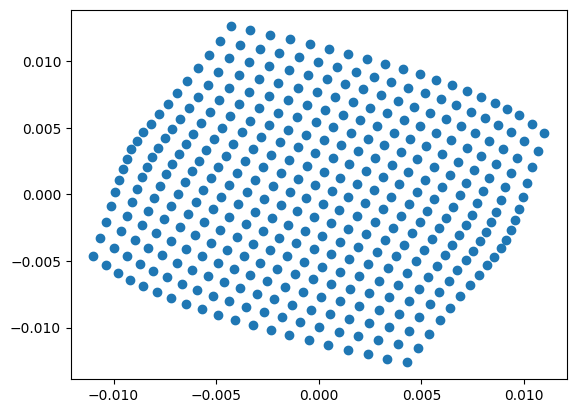

In [36]:
fig, ax = plt.subplots()
ax.scatter(z[:, 0], z[:, 1])

## `plot_graph`
Since `plot_graph` in Isomap only works for 64x64 images, we need to modify this function.